In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch
import numpy as np
from scipy.ndimage import convolve
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import glob
import torch.nn as nn
from torch import amp

Preparing the data

In [ ]:
class dataset_sr(Dataset):
    def __init__(self, kernel = np.ones((3, 3, 3)) / 27, stride = 4):
        final_states = []
        i = 0
        for f in sorted(glob.glob("data/final_states/state_*.npz")):
            final_states.append(np.load(f)["final_state"])
            i += 1
            if i %  10 == 0:
                print (f'{i} loaded', end = "\r")
        self.final_states = np.array(final_states)
        lr_size = self.final_states.shape[2] // stride
        self.lr_states = np.empty((self.final_states.shape[0], 5, lr_size, lr_size, lr_size))

        #for the moment im transforming all the images as soon as calling the dataset   
        for b in range(self.final_states.shape[0]):
            for c in range(self.final_states.shape[1]):
                self.lr_states[b, c] = convolve(self.final_states[b, c], kernel, mode = 'constant', cval = 0.0)[::stride, ::stride, ::stride]
                
    def __getitem__(self, index):
        return (
            torch.from_numpy(self.final_states[index]).float(),
            torch.from_numpy(self.lr_states[index]).float()
        )    
    def __len__(self):
        return len(self.final_states)


In [3]:
stride = 4
dataset = dataset_sr()

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


In [4]:
batch_size = 1
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 4, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = True, num_workers = 4, pin_memory = True)


Create the cnn

In [5]:
class CNN(nn.Module):
    def __init__(self, upscale_factor = 4):
        super(CNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv3d(5, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 5, kernel_size=3, padding=1))
                
    def forward(self, x):
        return self.net(x)

In [ ]:
def training_cnn(learning_rate, epochs, train_loader):
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cnn = CNN().to(device)
    optimizer = torch.optim.Adam(cnn.parameters(), lr=learning_rate)
    loss_cnn = nn.MSELoss()
    losses = []
    scaler = amp.GradScaler()

    for epoch in range(epochs):
        for high_res, low_res in train_loader:
            low_res = low_res.to(device)
            high_res = high_res.to(device)
            optimizer.zero_grad()
            with amp.autocast(device_type = 'cuda'):
                output = cnn(low_res)
                loss = loss_cnn(output, high_res)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{epochs}, loss={loss.item():.6f}", end='\r')

    return losses, cnn


In [7]:
losses, cnn = training_cnn(learning_rate = 0.005, epochs = 50, train_loader = train_loader)

In [ ]:
torch.save(cnn.state_dict(), 'model/cnn_basic')

In [ ]:
#cnn = CNN()
#cnn.load_state_dict(torch.load('model/cnn_basic', weights_only=True))
#cnn.eval()

CNN(
  (net): Sequential(
    (0): Conv3d(5, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU(inplace=True)
    (2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose3d(64, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (5): ReLU(inplace=True)
    (6): ConvTranspose3d(64, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (7): ReLU(inplace=True)
    (8): Conv3d(64, 5, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
)

In [8]:
import jax
import jax.numpy as jnp

# timing
from timeit import default_timer as timer

# jf1uids data structures
from jf1uids import SimulationConfig
from jf1uids import SimulationParams
from jf1uids.option_classes import WindConfig
from jf1uids.option_classes.simulation_config import BACKWARDS, OSHER, FORWARDS

# jf1uids setup functions
from jf1uids import get_helper_data
from jf1uids.fluid_equations.fluid import construct_primitive_state
from jf1uids.fluid_equations import total_quantities as tq
from jf1uids import get_registered_variables
from jf1uids.option_classes.simulation_config import finalize_config

# turbulent ic setup
from jf1uids.initial_condition_generation.turb import create_turb_field

# main simulation function
from jf1uids import time_integration

# units
from jf1uids import CodeUnits
from astropy import units as u
import astropy.constants as c

In [16]:
hr_state_test, lr_state_test_tensor = test_dataset[0]
hr_state_test, lr_state_test = hr_state_test.numpy(), lr_state_test_tensor.numpy()

In [10]:
print("👷 Setting up simulation...")

# simulation settings
gamma = 5/3

# spatial domain
box_size = 1.0

# resolution
num_cells = 128

# turbulence
turbulence = False
wanted_rms = 50 * u.km / u.s

fixed_timestep = False
dt_max = 0.1

# setup simulation config
config = SimulationConfig(
    runtime_debugging = False,
    first_order_fallback = False,
    progress_bar = True,
    dimensionality = 3,
    num_ghost_cells = 2,
    box_size = box_size, 
    num_cells = num_cells,
    fixed_timestep = fixed_timestep,
    differentiation_mode = FORWARDS,
    return_snapshots = True,
    num_snapshots = 80,
)

helper_data = get_helper_data(config)
registered_variables = get_registered_variables(config)

params = SimulationParams(
    dt_max = dt_max,
    gamma = gamma)

primitive_state = jnp.array(hr_state_test)
energy_hr_state = tq.calculate_total_energy(
    primitive_state = primitive_state, 
    helper_data = helper_data, 
    gamma = gamma, 
    gravitational_constant = c.G.value,
    config = config,
    registered_variables = registered_variables)

👷 Setting up simulation...


In [11]:
# resolution
num_cells = 128 // stride

# setup simulation config
config = SimulationConfig(
    runtime_debugging = False,
    first_order_fallback = False,
    progress_bar = True,
    dimensionality = 3,
    num_ghost_cells = 2,
    box_size = box_size, 
    num_cells = num_cells,
    fixed_timestep = fixed_timestep,
    differentiation_mode = FORWARDS,
    return_snapshots = True,
    num_snapshots = 80,
)

helper_data = get_helper_data(config)
registered_variables = get_registered_variables(config)

params = SimulationParams(
    dt_max = dt_max,
    gamma = gamma)

primitive_state = jnp.array(lr_state_test)
energy_lr_state = tq.calculate_total_energy(
    primitive_state = primitive_state, 
    helper_data = helper_data, 
    gamma = gamma, 
    gravitational_constant = c.G.value,
    config = config,
    registered_variables = registered_variables)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sr_state_test = cnn(lr_state_test_tensor.to(device))
sr_state_test = sr_state_test.cpu().detach().numpy()

In [57]:
print(sr_state_test.shape)

(5, 128, 128, 128)


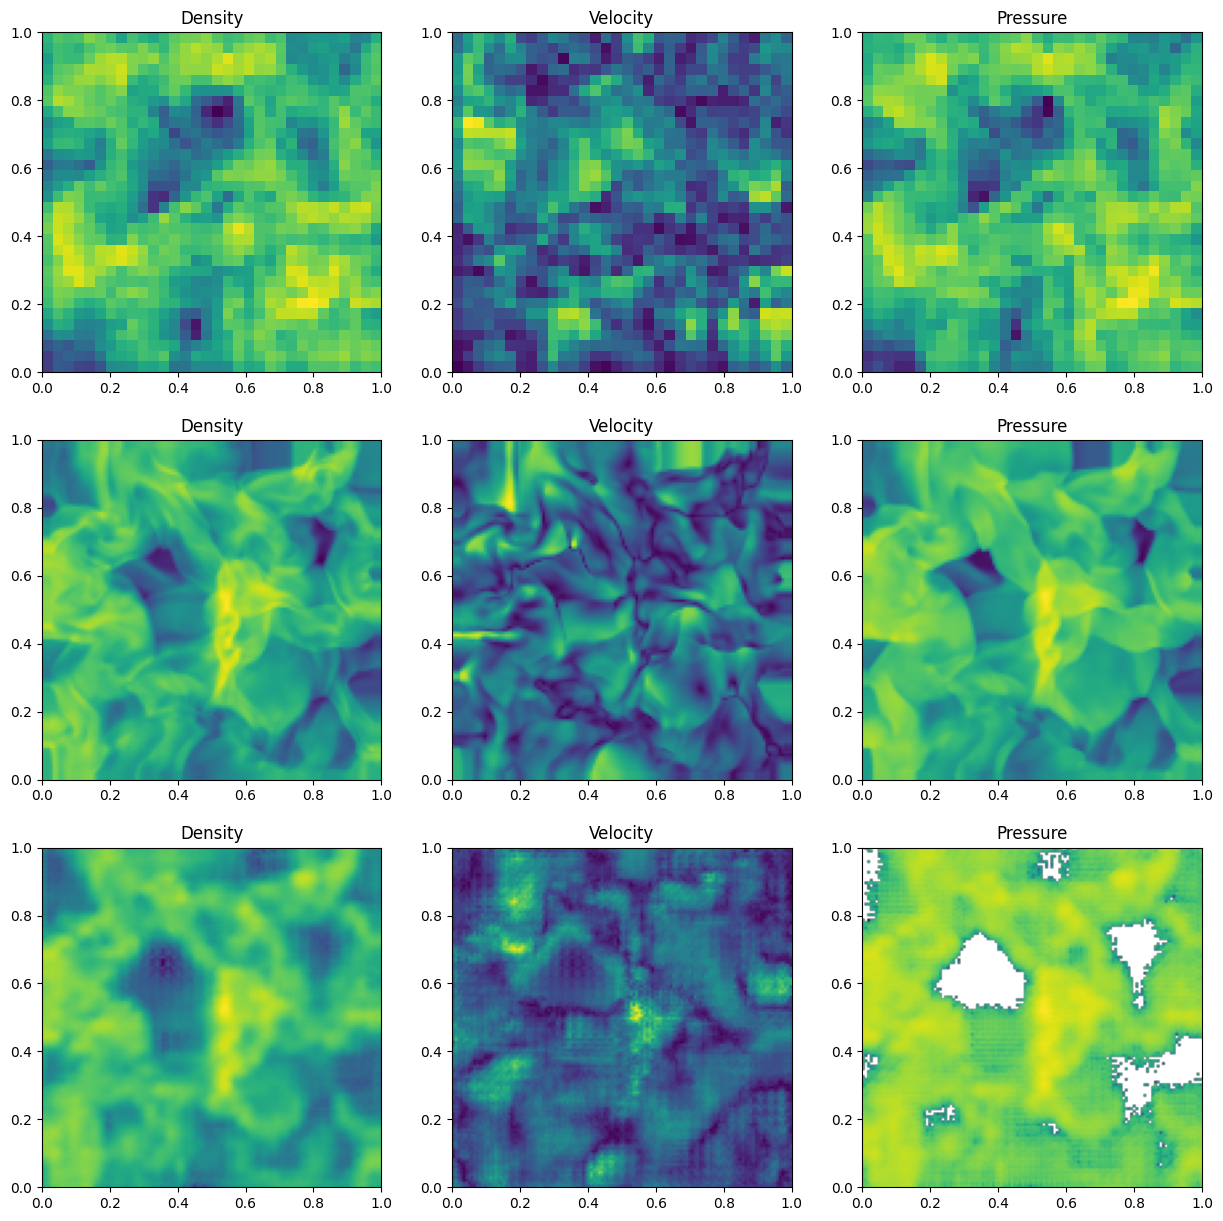

In [19]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# plot cuts at this z level
z_level = num_cells // 2
for i, state in enumerate([lr_state_test, hr_state_test, sr_state_test]):
    axes[i,0].imshow(state[0, :, :, z_level].T, origin = "lower", extent = [0, 1, 0, 1], norm = LogNorm())
    axes[i,0].set_title("Density")

    axes[i,1].imshow(jnp.sqrt(state[1, :, :, z_level]**2 + state[2, :, :, z_level]**2).T, origin = "lower", extent = [0, 1, 0, 1])
    axes[i,1].set_title("Velocity")

    axes[i,2].imshow(state[4, :, :, z_level].T, origin = "lower", extent = [0, 1, 0, 1], norm = LogNorm())
    axes[i,2].set_title("Pressure")

    # equal aspect ratio
    axes[i,0].set_aspect('equal', 'box')
    axes[i,1].set_aspect('equal', 'box')
    axes[i,2].set_aspect('equal', 'box')